In [1]:
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from tensorflow.keras.metrics import Recall

In [2]:

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [3]:
datadir = "C:\\Users\\20589\\Desktop\\Note\\sounds1"
#datadir = "./data"

In [4]:
from tqdm import tqdm

In [5]:
import os
import glob
import numpy as np
import librosa
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [6]:
# --- CONFIGURATION ---
AUDIO_DIR = "C:\\Users\\20589\\Desktop\\Note\\sounds1"
#AUDIO_DIR = "./data"  # Change this to your folder path
SR = 16000                             # Target sample rate (16kHz is standard for audio classification)
DURATION = 3.0                         # Duration in seconds to load/pad/trim each file
WINDOW_SIZE = 1.0                      # Time window size in seconds for input chunks
HOP_LENGTH = 0.5                       # Hop length for overlapping windows (50% overlap)
N_MELS = 64                            # Number of Mel frequency bins

In [7]:
file_paths = glob.glob(os.path.join(AUDIO_DIR, "*.wav"))


In [8]:
filename = os.path.basename(file_paths[10])

In [9]:
filename.startswith("OK")

False

In [10]:
def extract_windows_from_file(file_path):
    """Loads an audio file, slices it into overlapping time windows, 
    and converts each window into a Mel Spectrogram."""
    # Load audio (automatically resampled to SR, forced to mono)
    y, sr = librosa.load(file_path, sr=SR, duration=DURATION)
    
    # Ensure standard length (pad with zeros if too short, trim if too long)
    target_len = int(DURATION * SR)
    if len(y) < target_len:
        y = librosa.util.pad_center(y, size=target_len)
    else:
        y = y[:target_len]
        
    window_len = int(WINDOW_SIZE * SR)
    hop_len = int(HOP_LENGTH * SR)
    
    spectrograms = []
    
    # Frame the audio into overlapping time windows
    # frame shape: (window_len, num_frames)
    frames = librosa.util.frame(y, frame_length=window_len, hop_length=hop_len)
    
    for i in range(frames.shape[1]):
        frame_data = frames[:, i]
        
        # Convert the time window to a Mel Spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=frame_data, sr=SR, n_mels=N_MELS, n_fft=1024, hop_length=256
        )
        # Convert power to decibels (log scale, matches human hearing better)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        spectrograms.append(mel_spec_db)
        
    return spectrograms

In [11]:
librosa.load

g:\python\venv\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<function librosa.core.audio.load(path: 'Union[str, int, os.PathLike[Any], sf.SoundFile, audioread.AudioFile, BinaryIO]', *, sr: 'Optional[float]' = 22050, mono: 'bool' = True, offset: 'float' = 0.0, duration: 'Optional[float]' = None, dtype: 'DTypeLike' = <class 'numpy.float32'>, res_type: 'str' = 'soxr_hq') -> 'Tuple[np.ndarray, Union[int, float]]'>

In [12]:
DURATION

3.0

In [13]:
y, sr = librosa.load(file_paths[10], sr=SR, duration=DURATION)

In [14]:
from matplotlib import pyplot as plt

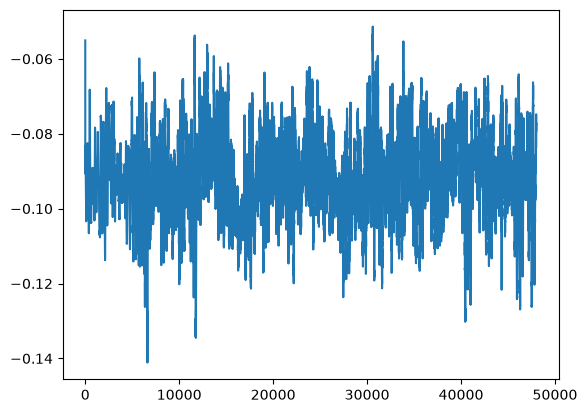

In [15]:
plt.plot(y)

In [16]:
file_paths[30]

'C:\\Users\\20589\\Desktop\\Note\\sounds1\\NG_a1_群组0_260508_13_36_12.wav'

In [17]:


                        



# --- DATA LOADING ---
X = []
y = []

# Find all wav files
file_paths = glob.glob(os.path.join(AUDIO_DIR, "*.wav"))

if not file_paths:
    raise ValueError(f"No .wav files found in {AUDIO_DIR}. Check your path!")

print(f"Processing {len(file_paths)} audio files...")

for path in tqdm(file_paths):
    print(path)
    filename = os.path.basename(path)
    
    # Determine label based on prefix   
    if filename.startswith("OK"):
        label = 0  # Normal
    elif filename.startswith("NG"):
        label = 1  # Abnormal (No Good)
    else:
        continue   # Skip files that don't match our criteria
        
    try:
        # Extract all time windows from this file
        windows = extract_windows_from_file(path)
        for spec in windows:
            X.append(spec)
            y.append(label)
    except Exception as e:
        print(f"Error processing {filename}: {e}")

X = np.array(X)
y = np.array(y)

# Add a channel dimension for the CNN (height, width, channels)
X = np.expand_dims(X, axis=-1)

print(f"Total dataset shape (Windows, Mel Bins, Time Steps, Channels): {X.shape}")
print(f"Label distribution (0=OK, 1=NG): {np.bincount(y)}")

# --- TRAIN/TEST SPLIT ---
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- MODEL BUILDING ---
# A lightweight CNN is perfect for spectrogram features
input_shape = (X.shape[1], X.shape[2], 1)

from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight = dict(zip(classes, cw))
print("class_weight:", class_weight)

from tensorflow.keras.regularizers import l2

reg = l2(1e-4)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_shape),
    
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=reg),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),
    
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=reg),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),
    
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    # Sigmoid activation outputs a probability between 0 and 1 for binary classification
    tf.keras.layers.Dense(1, activation='sigmoid') 
])

# Use BinaryCrossentropy for binary classification tasks
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),Recall(name='recall')]
)

model.summary()

# --- TRAINING ---
print("\nStarting training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[
        # Stop early if validation loss stops improving to prevent overfitting
        tf.keras.callbacks.EarlyStopping(monitor='val_recall',mode='max',patience=6, restore_best_weights=True)
    ]
)

Processing 91 audio files...


  1%|          | 1/91 [00:00<00:15,  5.80it/s]

C:\Users\20589\Desktop\Note\sounds1\NG_a0_群组0_260428_14_25_55.wav
C:\Users\20589\Desktop\Note\sounds1\NG_a0_群组0_260428_14_28_13.wav
C:\Users\20589\Desktop\Note\sounds1\NG_a0_群组0_260430_09_29_35.wav
C:\Users\20589\Desktop\Note\sounds1\NG_a1_群组0_260428_14_06_41.wav


 16%|█▋        | 15/91 [00:00<00:01, 45.21it/s]

C:\Users\20589\Desktop\Note\sounds1\NG_a1_群组0_260428_14_10_03.wav
C:\Users\20589\Desktop\Note\sounds1\NG_a1_群组0_260428_14_12_29.wav
C:\Users\20589\Desktop\Note\sounds1\NG_a1_群组0_260428_14_14_39.wav
C:\Users\20589\Desktop\Note\sounds1\NG_a1_群组0_260428_14_16_52.wav
C:\Users\20589\Desktop\Note\sounds1\NG_a1_群组0_260428_14_18_50.wav
C:\Users\20589\Desktop\Note\sounds1\NG_a1_群组0_260428_14_20_58.wav
C:\Users\20589\Desktop\Note\sounds1\NG_a1_群组0_260428_14_22_59.wav
C:\Users\20589\Desktop\Note\sounds1\NG_a1_群组0_260428_15_20_05.wav
C:\Users\20589\Desktop\Note\sounds1\NG_a1_群组0_260429_10_21_59.wav
C:\Users\20589\Desktop\Note\sounds1\NG_a1_群组0_260429_10_25_05.wav
C:\Users\20589\Desktop\Note\sounds1\NG_a1_群组0_260429_10_27_35.wav
C:\Users\20589\Desktop\Note\sounds1\NG_a1_群组0_260429_10_37_13.wav
C:\Users\20589\Desktop\Note\sounds1\NG_a1_群组0_260429_10_41_47.wav
C:\Users\20589\Desktop\Note\sounds1\NG_a1_群组0_260430_09_32_38.wav


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 61, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 61, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,425 (91.50 KB)

 Trainable params: 23,233 (90.75 KB)

 Non-trainable params: 192 (768.00 B)


Starting training...
Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.4753 - auc: 0.5040 - loss: 0.7555 - recall: 0.3250 - val_accuracy: 0.5604 - val_auc: 0.5703 - val_loss: 0.8659 - val_recall: 0.0000e+00
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.4863 - auc: 0.4623 - loss: 0.7754 - recall: 0.4125 - val_accuracy: 0.5604 - val_auc: 0.5902 - val_loss: 0.8398 - val_recall: 0.0000e+00
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.5330 - auc: 0.5357 - loss: 0.7382 - recall: 0.5312 - val_accuracy: 0.5604 - val_auc: 0.5775 - val_loss: 0.8168 - val_recall: 0.0000e+00
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.4973 - auc: 0.5144 - loss: 0.7415 - recall: 0.5250 - val_accuracy: 0.5604 - val_auc: 0.5917 - val_loss: 0.8106 - val_recall: 0.0000e+00
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5165 - auc: 0.5395 - loss: 0.7246 - recall: 0.5688 - val_accuracy: 0.5604 - val_auc: 0.5941 - val_loss: 0.797

In [18]:
X_train.shape

(364, 64, 63, 1)